# Assignment 1 2AMM10 2025-2026

## Group: Working Title
### Member 1: Neha Bogavarapu
### Member 2: Sofie van Engelen (2224402)
### Member 3: Mees Peters

## Task 1 

Dataset and visualization

In [12]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else: 
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

In [13]:
from torchvision import transforms
from torch.utils.data import DataLoader

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

BATCH_SIZE = 32
IMAGE_SIZE = 64
EMBED_DIM = 128

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# Dataloaders
train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
support_new_loader = DataLoader(support_new_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_new_loader = DataLoader(test_new_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [14]:
import torch.nn as nn
import torch.nn.functional as F

class EmbeddingCNN(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.embedding = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        x = self.embedding(x)

        x = F.normalize(x, p=2, dim=1)
        return x

In [15]:
def batch_hard_triplet_loss(embeddings, labels, margin=0.3):
    """
    embeddings: Tensor of shape (B, D)
    labels: Tensor of shape (B,)
    """
    distances = torch.cdist(embeddings, embeddings, p=2)

    labels = labels.view(-1, 1)

    same_label = labels == labels.T
    different_label = labels != labels.T

    eye = torch.eye(labels.size(0), dtype=torch.bool, device=labels.device)

    positive_mask = same_label & ~eye
    negative_mask = different_label

    hardest_positive = distances.masked_fill(~positive_mask, -1e9).max(dim=1).values
    hardest_negative = distances.masked_fill(~negative_mask, 1e9).min(dim=1).values

    valid_anchor = positive_mask.any(dim=1)

    if valid_anchor.sum() == 0:
        return torch.tensor(0.0, device=embeddings.device, requires_grad=True)

    loss = F.relu(hardest_positive - hardest_negative + margin)

    return loss[valid_anchor].mean()

Valid batches: 96
Epoch [1/15] - Loss: 0.0486
Valid batches: 96
Epoch [2/15] - Loss: 0.0069
Valid batches: 96
Epoch [3/15] - Loss: 0.0061
Valid batches: 96
Epoch [4/15] - Loss: 0.0025
Valid batches: 96
Epoch [5/15] - Loss: 0.0029
Valid batches: 96
Epoch [6/15] - Loss: 0.0006
Valid batches: 96
Epoch [7/15] - Loss: 0.0002
Valid batches: 96
Epoch [8/15] - Loss: 0.0006
Valid batches: 96
Epoch [9/15] - Loss: 0.0068
Valid batches: 96
Epoch [10/15] - Loss: 0.0019
Valid batches: 96
Epoch [11/15] - Loss: 0.0011
Valid batches: 96
Epoch [12/15] - Loss: 0.0024
Valid batches: 96
Epoch [13/15] - Loss: 0.0012
Valid batches: 96
Epoch [14/15] - Loss: 0.0009
Valid batches: 96
Epoch [15/15] - Loss: 0.0014


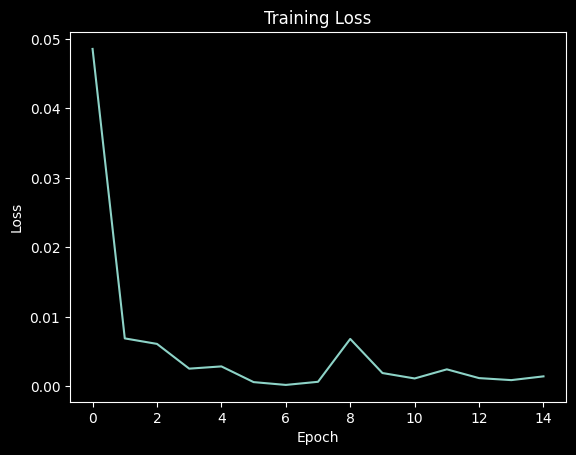

In [17]:
# Training loop
model = EmbeddingCNN(
    embedding_dim=EMBED_DIM
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS = 15

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        embeddings = model(images)

        # Metric learning loss
        loss = batch_hard_triplet_loss(
            embeddings,
            labels,
            margin=0.3
        )

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Valid batches: {len(train_loader)}")
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {epoch_loss:.4f}")

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

torch.save(model.state_dict(), "saved_models/task1_embedding_model.pth")

In [18]:
def extract_embeddings(model, loader):
    model.eval()

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embeddings = model(images)

            all_embeddings.append(embeddings.detach().cpu())
            all_labels.append(labels.detach().cpu())

    all_embeddings = torch.cat(all_embeddings)
    all_labels = torch.cat(all_labels)

    return all_embeddings, all_labels

def nearest_neighbor_predict(query_embeddings, support_embeddings, support_labels):
    distances = torch.cdist(query_embeddings, support_embeddings, p=2)
    nearest_indices = distances.argmin(dim=1)
    predictions = support_labels[nearest_indices]
    return predictions

In [19]:
train_embeddings, train_labels = extract_embeddings(model, train_loader)
test_embeddings, test_labels = extract_embeddings(model, test_loader)
support_new_embeddings, support_new_labels = extract_embeddings(model, support_new_loader)
test_new_embeddings, test_new_labels = extract_embeddings(model, test_new_loader)

seen_predictions = nearest_neighbor_predict(test_embeddings, train_embeddings, train_labels)
unseen_predictions = nearest_neighbor_predict(test_new_embeddings, support_new_embeddings, support_new_labels)

seen_accuracy = (seen_predictions == test_labels).float().mean().item()
unseen_accuracy = (unseen_predictions == test_new_labels).float().mean().item()

print(f"Seen item accuracy: {seen_accuracy * 100:.2f}%")
print(f"Unseen item accuracy: {unseen_accuracy * 100:.2f}%")

Seen item accuracy: 94.80%
Unseen item accuracy: 90.40%


## Task 2

In [ ]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0]) 

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

In [ ]:
train_data = GardenDataset(subset="train", transform=transform)

# scenario 1 
test_data = GardenDataset(subset="test", transform=transform)

# scenario 2 
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")

# scenario 3 
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")

# scenario 4 
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all",class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new",class_level="family")

# your code here

## Task 3

In [ ]:
train_data_both = GardenDataset(class_level="both",transform=transform,subset="train",family_subset="main",item_subset="main")

test_data_both = GardenDataset(class_level="both",transform=transform,subset="test",family_subset="main",item_subset="main")

# your code here

## Task 4

In [ ]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).
    
    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        BlackoutPixels(fraction=fraction),
        ... # your transforms here
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here
